In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

ModuleNotFoundError: No module named 'kagglehub'

# Business Problem:
**توقَّع العملاء المحتمل تحولهم إلى عملاء فعليين بناءً على بياناتهم الديموغرافية والسلوكية**
# Target Variable:
**Conversion**
# Class 0 :
**No Conversion**
# Class 1:
**Conversion**



# ML Problem Type:
**Binary Classification**

In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/digital_marketing_campaign_dataset.csv")

df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

| اسم العمود (Column) | الترجمة والمعنى باللغة العربية |
| --- | --- |
| **CustomerID** | المعرف الفريد للعميل (رقم العميل) |
| **Age** | عمر العميل |
| **Gender** | الجنس (ذكر / أنثى) |
| **Income** | الدخل المادي للعميل |
| **CampaignChannel** | قناة الحملة التسويقية (مثل: البريد، التواصل الاجتماعي) |
| **CampaignType** | نوع الحملة التسويقية (مثل: إعادة استهداف، زيادة المبيعات) |
| **AdSpend** | الإنفاق الإعلاني (المبلغ المنفق على الإعلان) |
| **ClickThroughRate** | معدل النقر إلى الظهور (CTR) |
| **ConversionRate** | معدل التحويل (نسبة من قاموا بالإجراء المطلوب) |
| **WebsiteVisits** | عدد زيارات الموقع الإلكتروني |
| **PagesPerVisit** | عدد الصفحات المزارة في كل زيارة |
| **TimeOnSite** | الوقت المستغرق داخل الموقع |
| **SocialShares** | عدد المشاركات على وسائل التواصل الاجتماعي |
| **EmailOpens** | عدد مرات فتح البريد الإلكتروني |
| **EmailClicks** | عدد النقرات داخل البريد الإلكتروني |
| **PreviousPurchases** | عدد عمليات الشراء السابقة |
| **LoyaltyPoints** | نقاط الولاء والمكافآت |
| **AdvertisingPlatform** | المنصة الإعلانية (مثل: Google, Meta) |
| **AdvertisingTool** | الأداة الإعلانية المستخدمة |
| **Conversion** | إتمام التحويل/الشراء (1 = تم الشراء، 0 = لم يتم) |

In [ ]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [ ]:
df.describe(include='object')

,Gender,CampaignChannel,CampaignType,AdvertisingPlatform,AdvertisingTool
count,8000,8000,8000,8000,8000
unique,2,5,4,1,1
top,Female,Referral,Conversion,IsConfid,ToolConfid
freq,4839,1719,2077,8000,8000


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Gender
['Female' 'Male']

CampaignChannel
['Social Media' 'Email' 'PPC' 'Referral' 'SEO']

CampaignType
['Awareness' 'Retention' 'Conversion' 'Consideration']

AdvertisingPlatform
['IsConfid']

AdvertisingTool
['ToolConfid']


In [ ]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,8000.0,11999.500000,2309.545410,8000.000000,9999.750000,11999.500000,13999.250000,15999.000000
Age,8000.0,43.625500,14.902785,18.000000,31.000000,43.000000,56.000000,69.000000
Income,8000.0,84664.196750,37580.387945,20014.000000,51744.500000,84926.500000,116815.750000,149986.000000
AdSpend,8000.0,5000.944830,2838.038153,100.054813,2523.221165,5013.440044,7407.989369,9997.914781
ClickThroughRate,8000.0,0.154829,0.084007,0.010005,0.082635,0.154505,0.228207,0.299968
ConversionRate,8000.0,0.104389,0.054878,0.010018,0.056410,0.104046,0.152077,0.199995
WebsiteVisits,8000.0,24.751625,14.312269,0.000000,13.000000,25.000000,37.000000,49.000000
PagesPerVisit,8000.0,5.549299,2.607358,1.000428,3.302479,5.534257,7.835756,9.999055
TimeOnSite,8000.0,7.727718,4.228218,0.501669,4.068340,7.682956,11.481468,14.995311
SocialShares,8000.0,49.799750,28.901165,0.000000,25.000000,50.000000,75.000000,99.000000


# مفيش اي Invalid Values

In [ ]:
df = df.drop(columns=['CustomerID'])

In [ ]:
df = df.drop(columns=['AdvertisingPlatform', 'AdvertisingTool'])

**حذفتهم لانه مش هيضيفوا مفعلومه جديده**

In [ ]:
target_distribution = pd.DataFrame({
    'Count': df['Conversion'].value_counts(),
    'Percentage': df['Conversion'].value_counts(normalize=True) * 100
})

target_distribution

,Count,Percentage
Conversion,,
1,7012,87.65
0,988,12.35


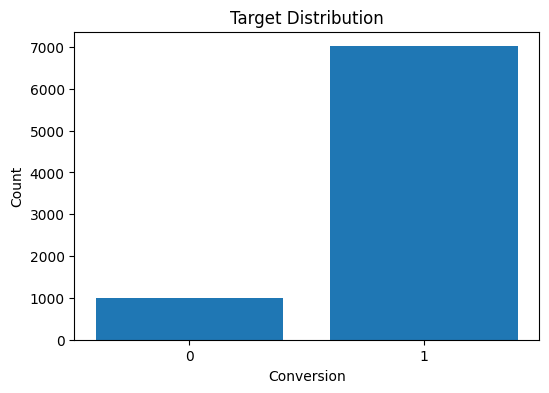

In [ ]:
import matplotlib.pyplot as plt

target_counts = df['Conversion'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)

plt.xlabel('Conversion')
plt.ylabel('Count')
plt.title('Target Distribution')

plt.show()

# Class Imbalance

In [ ]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()

numerical_features = [col for col in numerical_cols if col != 'Conversion']

print(numerical_features)

['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


In [ ]:
df[numerical_features].skew().sort_values()

WebsiteVisits       -0.017139
PagesPerVisit       -0.012510
SocialShares        -0.011357
Income              -0.011298
Age                 -0.004916
PreviousPurchases    0.005712
EmailOpens           0.007679
ClickThroughRate     0.011066
ConversionRate       0.012777
TimeOnSite           0.014610
LoyaltyPoints        0.016303
AdSpend              0.019224
EmailClicks          0.023366
dtype: float64

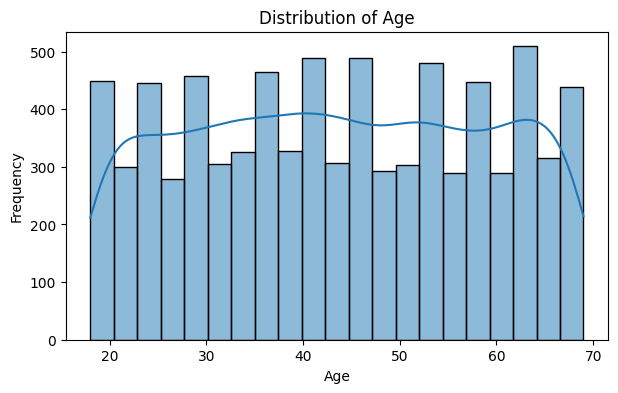

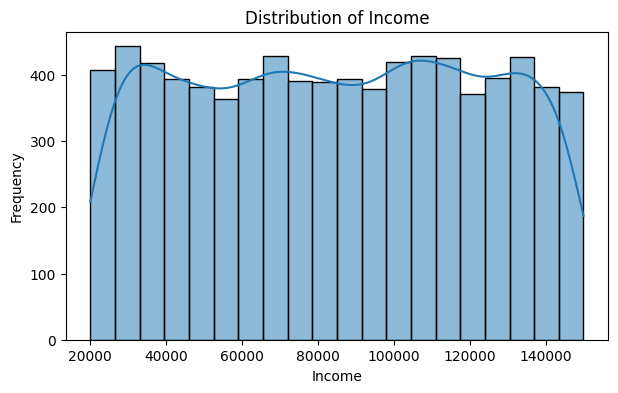

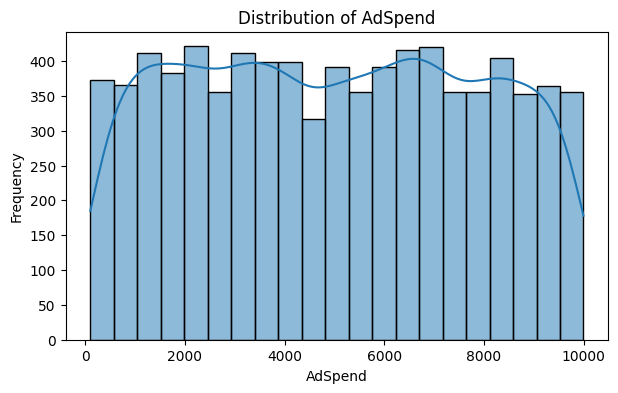

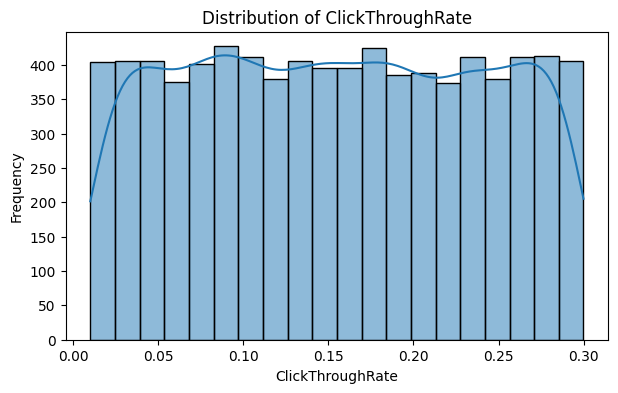

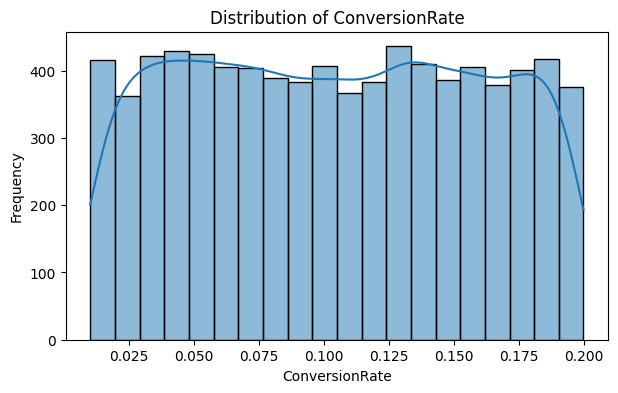

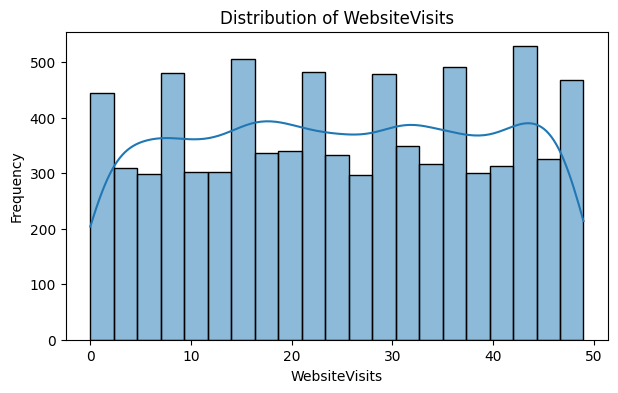

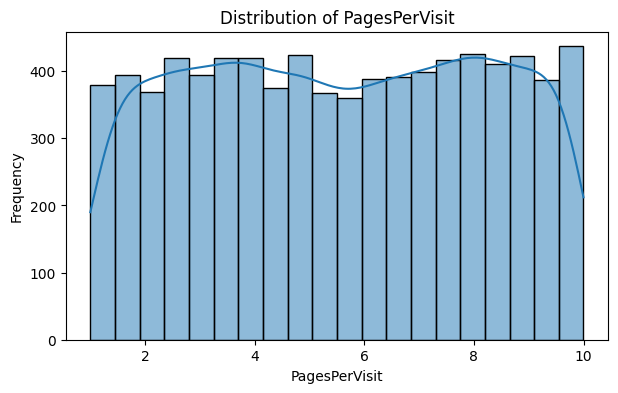

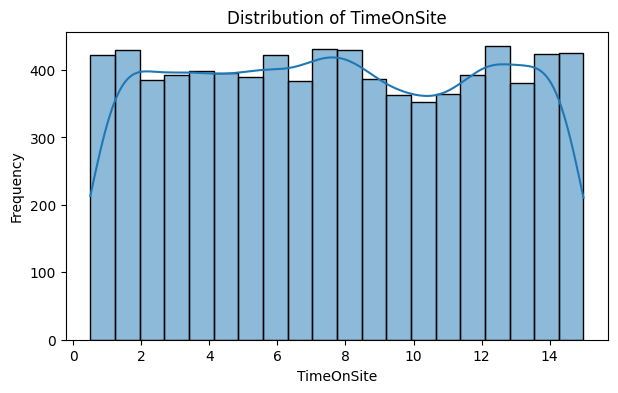

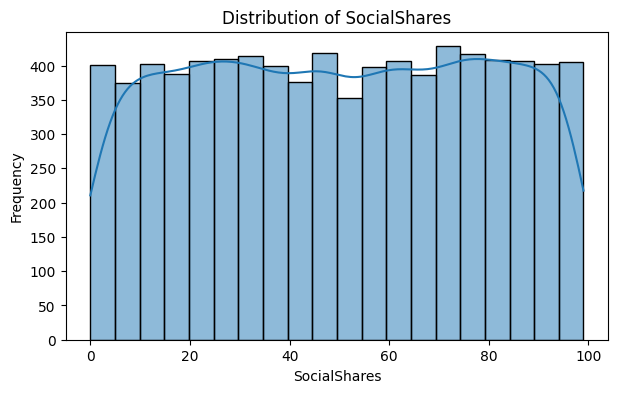

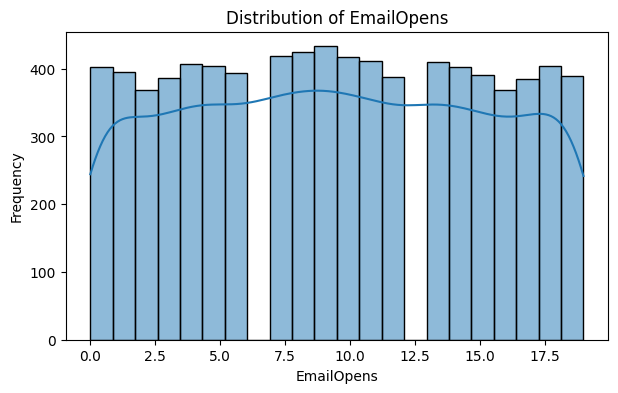

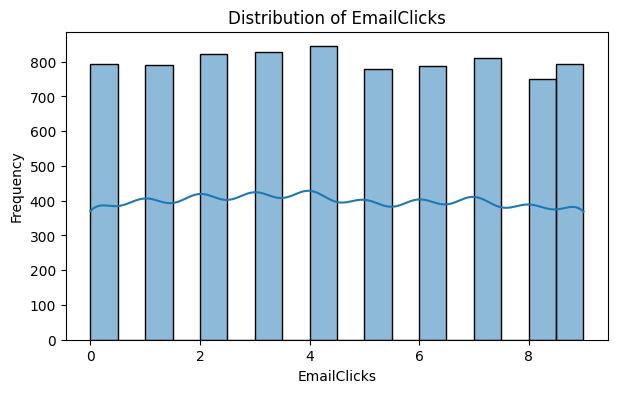

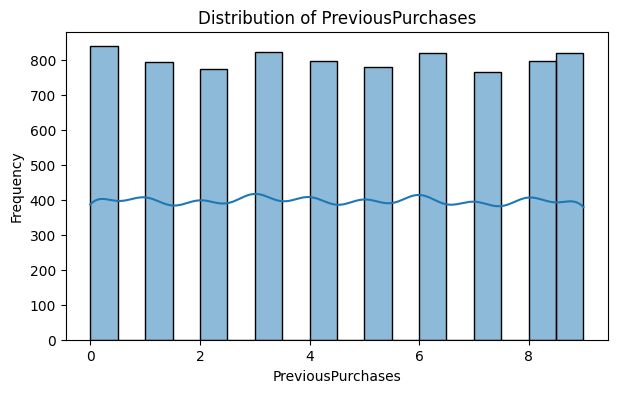

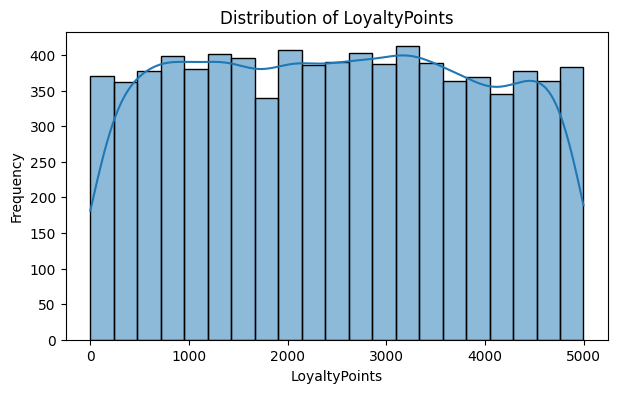

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_features:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        data=df,
        x=col,
        kde=True
    )
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.show()

**لم يتم اكتشاف  (Skewness)**
**------------------------------------------------------------**
**و دا مش معناه ان مفيش Outliers**

In [ ]:
categorical_features = ['Gender', 'CampaignChannel', 'CampaignType']

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).mul(100).round(2))


--- Gender ---
Gender
Female    4839
Male      3161
Name: count, dtype: int64
Gender
Female    60.49
Male      39.51
Name: proportion, dtype: float64

--- CampaignChannel ---
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64
CampaignChannel
Referral        21.49
PPC             20.69
Email           19.46
SEO             19.38
Social Media    18.99
Name: proportion, dtype: float64

--- CampaignType ---
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64
CampaignType
Conversion       25.96
Awareness        24.85
Consideration    24.85
Retention        24.34
Name: proportion, dtype: float64


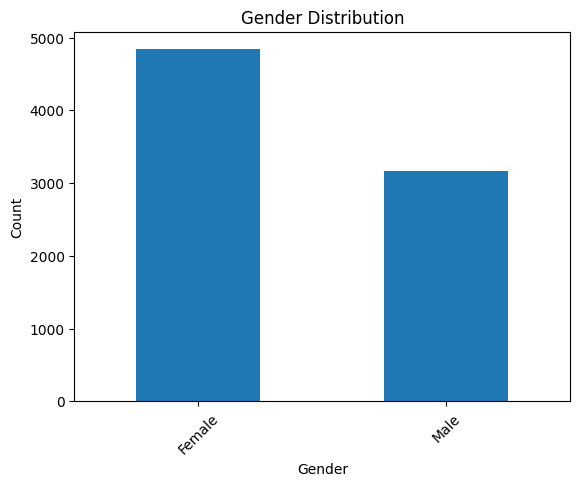

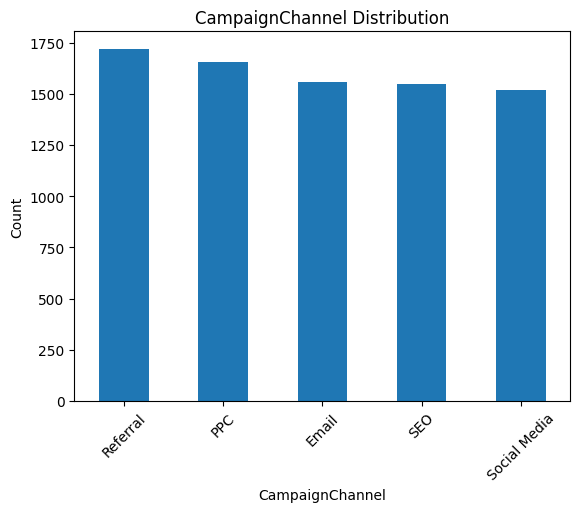

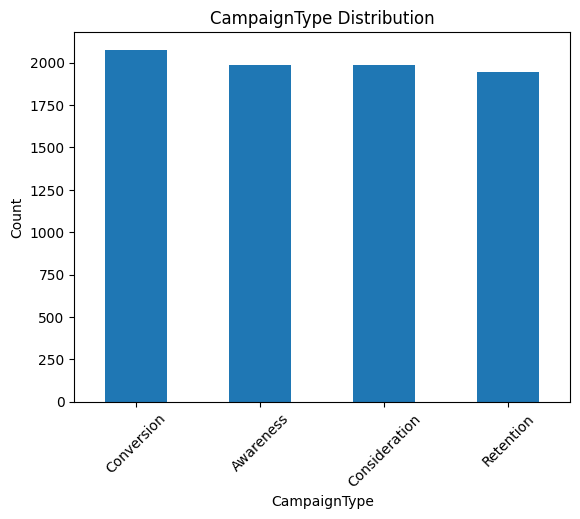

In [ ]:
import matplotlib.pyplot as plt

for col in categorical_features:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

**مفيش مشكله ظاهره في توزيع Categorical Features.**

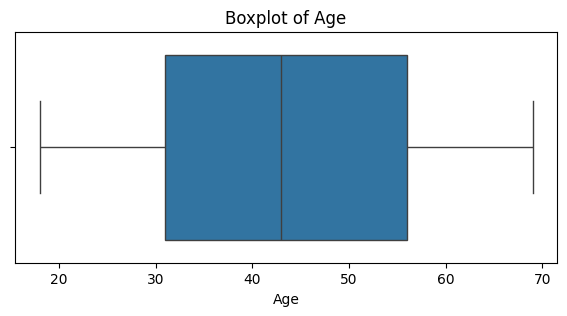

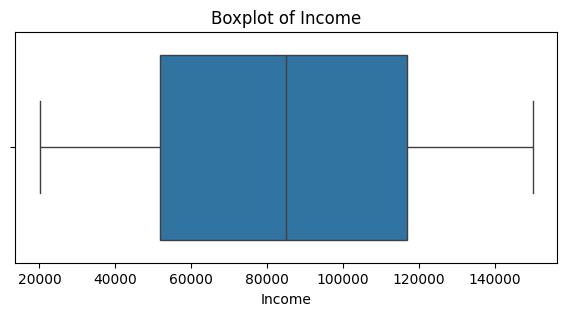

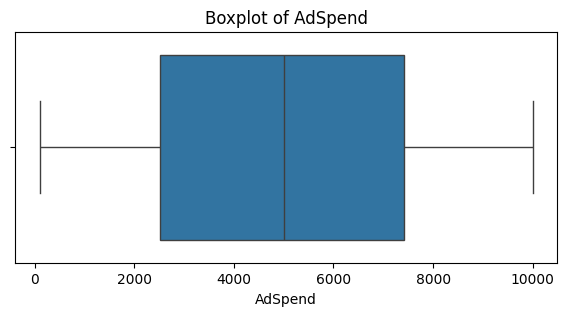

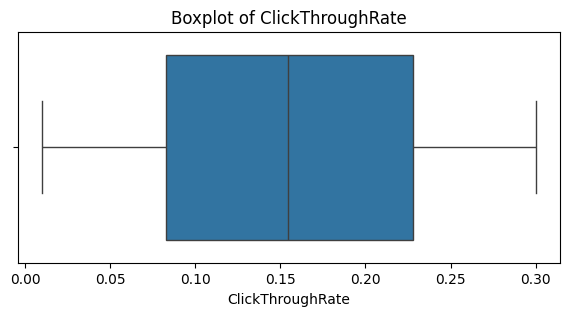

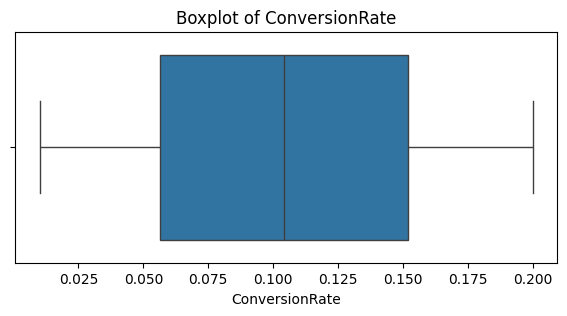

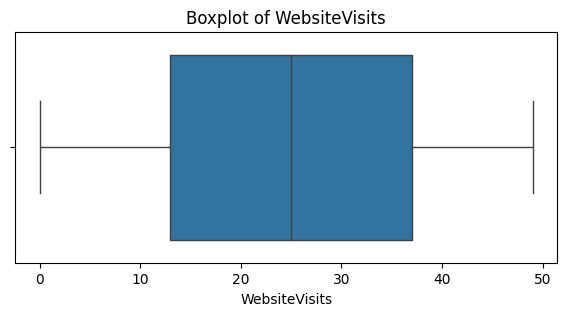

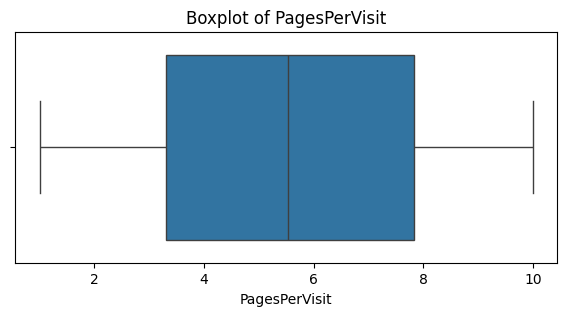

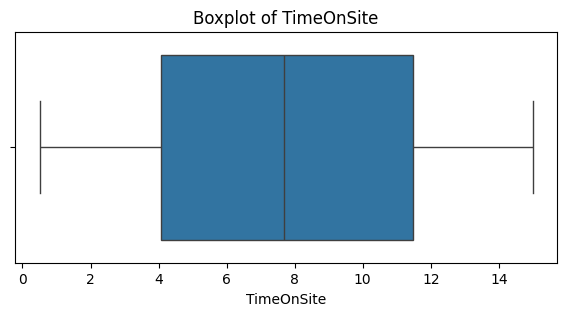

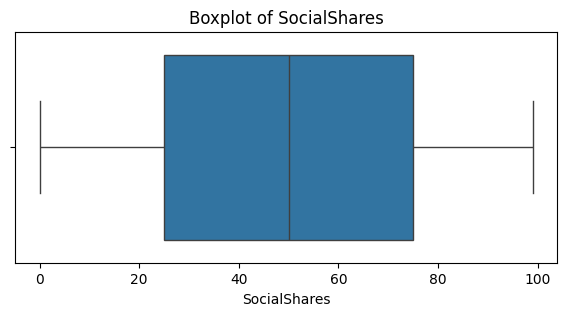

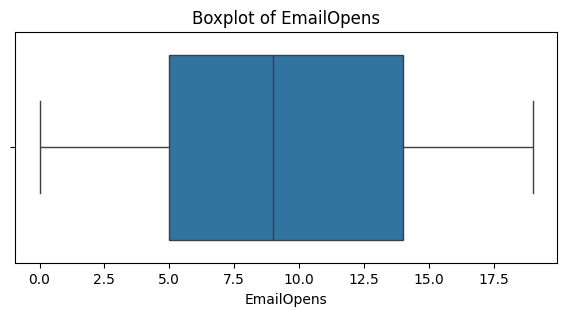

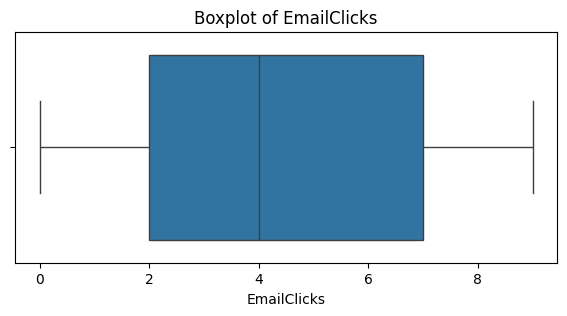

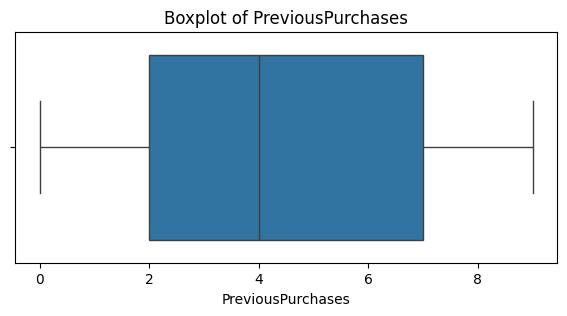

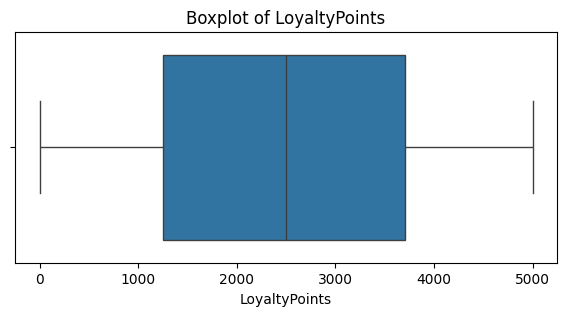

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_features:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = outliers / len(df) * 100
    
    print(f"{col}: {outliers} ({percentage:.2f}%)")

Age: 0 (0.00%)
Income: 0 (0.00%)
AdSpend: 0 (0.00%)
ClickThroughRate: 0 (0.00%)
ConversionRate: 0 (0.00%)
WebsiteVisits: 0 (0.00%)
PagesPerVisit: 0 (0.00%)
TimeOnSite: 0 (0.00%)
SocialShares: 0 (0.00%)
EmailOpens: 0 (0.00%)
EmailClicks: 0 (0.00%)
PreviousPurchases: 0 (0.00%)
LoyaltyPoints: 0 (0.00%)


In [ ]:
for col in numerical_features:
    print(f"\n--- {col} ---")
    print(df.groupby('Conversion')[col].agg(['mean', 'median']))


--- Age ---
                 mean  median
Conversion                   
0           43.561741    44.0
1           43.634484    43.0

--- Income ---
                    mean   median
Conversion                       
0           83265.308704  83876.0
1           84861.301911  85124.5

--- AdSpend ---
                   mean       median
Conversion                          
0           4058.398466  3554.554979
1           5133.750850  5249.718686

--- ClickThroughRate ---
                mean    median
Conversion                    
0           0.127972  0.103357
1           0.158613  0.159202

--- ConversionRate ---
                mean    median
Conversion                    
0           0.090766  0.081513
1           0.106308  0.106523

--- WebsiteVisits ---
                 mean  median
Conversion                   
0           21.726721    20.0
1           25.177838    25.0

--- PagesPerVisit ---
                mean    median
Conversion                    
0           4.835002  4.

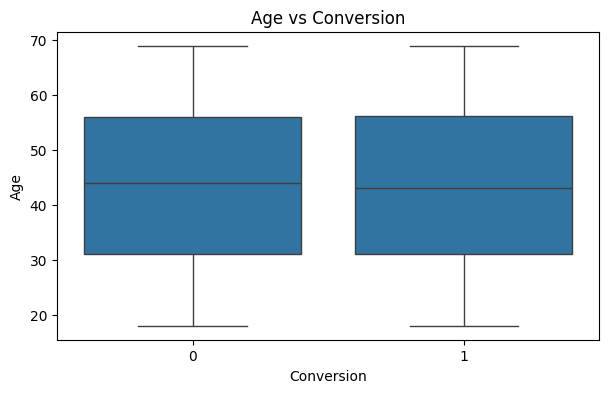

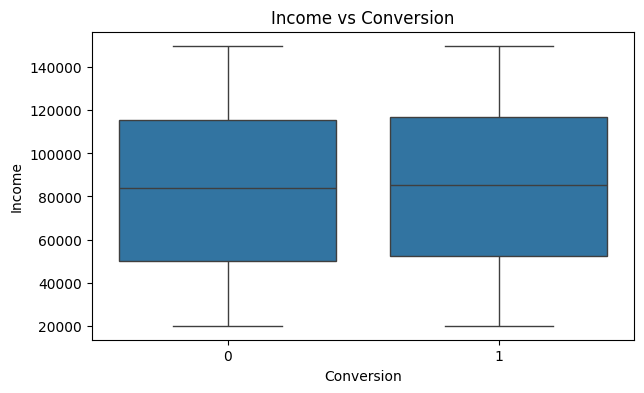

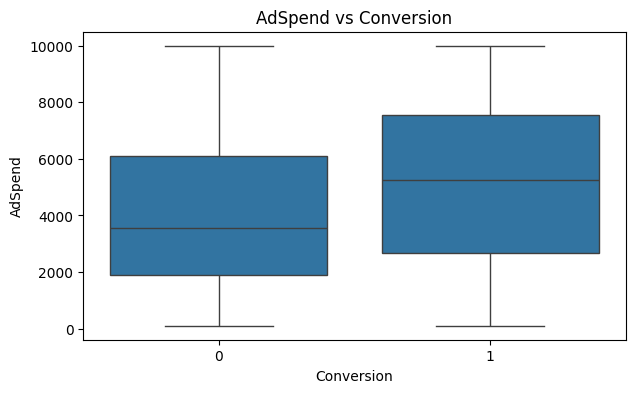

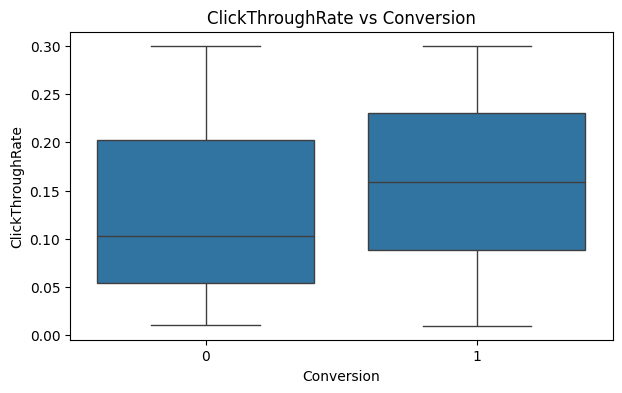

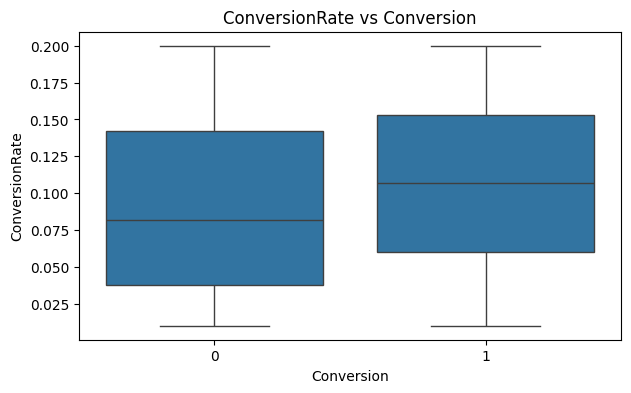

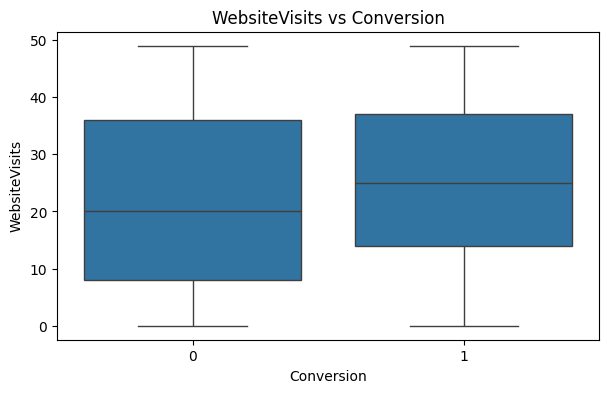

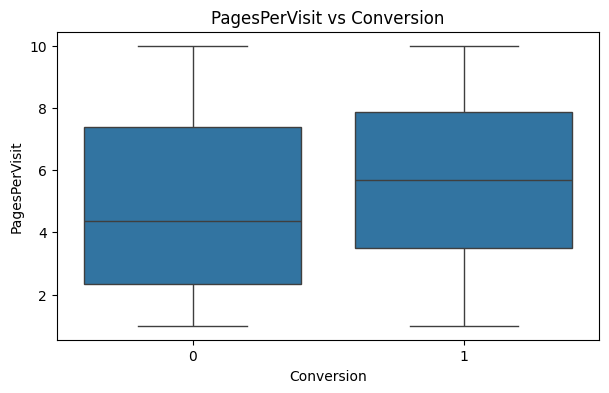

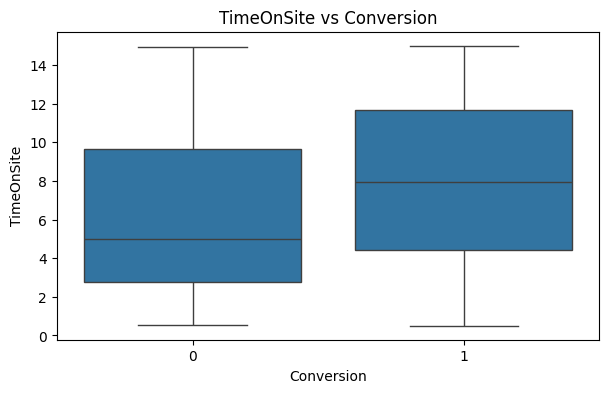

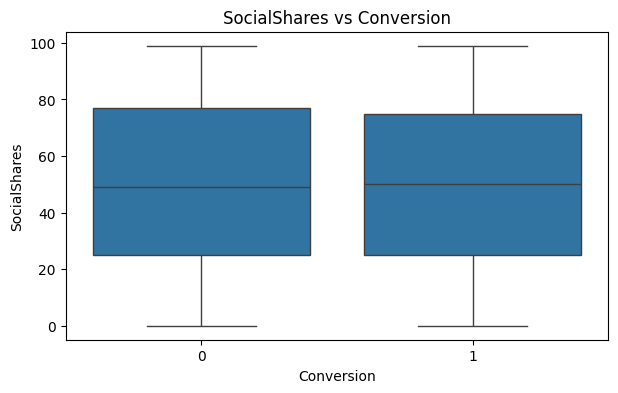

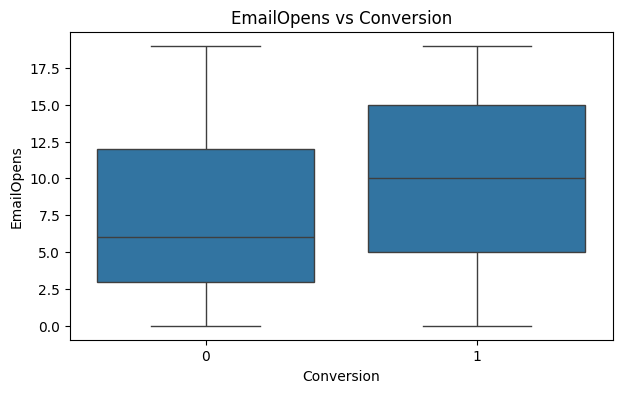

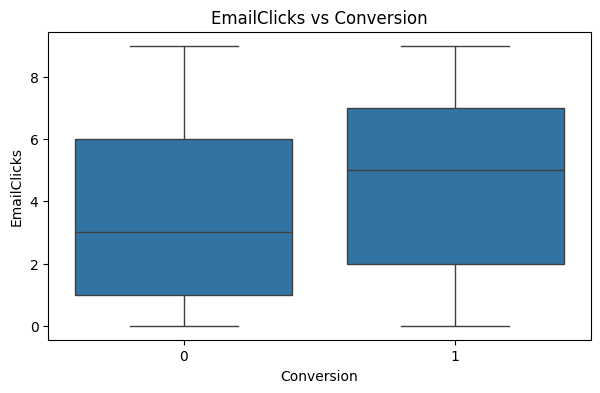

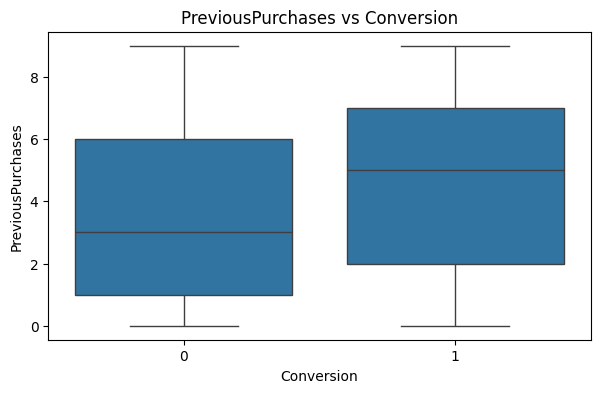

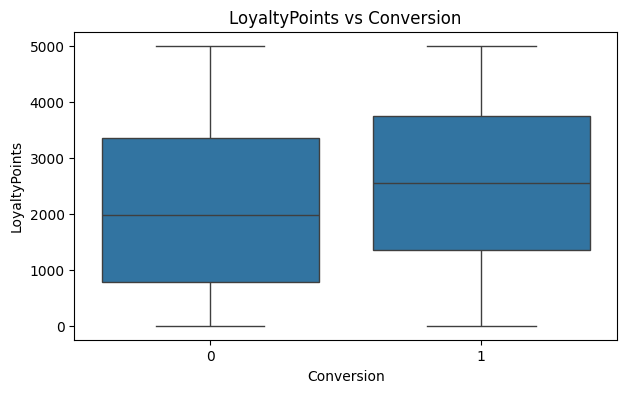

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_features:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=df, x='Conversion', y=col)
    
    plt.title(f'{col} vs Conversion')
    plt.xlabel('Conversion')
    plt.ylabel(col)
    
    plt.show()



* * 1. أهم الملاحظات من Numerical Features vs ConversionAge: لا يوجد فرق واضح بين المجموعتين؛ المتوسط تقريبًا 43.6 سنة في الحالتين.Income: العملاء الذين قاموا بالتحويل لديهم دخل أعلى قليلًا من غير المحولين.AdSpend: المحولون لديهم إنفاق إعلاني أعلى بشكل واضح.ClickThroughRate: الـ CTR أعلى لدى العملاء الذين قاموا بالتحويل.ConversionRate: أعلى لدى المحولين، لكن تحتاج مراجعة لاحتمالية وجود Data Leakage.WebsiteVisits: المحولون لديهم عدد زيارات للموقع أعلى.PagesPerVisit: المحولون يشاهدون صفحات أكثر في الزيارة.TimeOnSite: المحولون يقضون وقتًا أطول على الموقع.SocialShares: لا يوجد فرق واضح بين المجموعتين.EmailOpens: المحولون لديهم عدد أكبر من فتحات البريد الإلكتروني.EmailClicks: المحولون لديهم نقرات بريد إلكتروني أكثر.PreviousPurchases: المحولون لديهم مشتريات سابقة أكثر.LoyaltyPoints: المحولون لديهم نقاط ولاء أعلى.* * 


In [ ]:
categorical_features = [
    'Gender',
    'CampaignChannel',
    'CampaignType'
]

for col in categorical_features:
    print(f"\n--- {col} vs Conversion ---")
    print(
        pd.crosstab(
            df[col],
            df['Conversion'],
            normalize='index'
        ).round(2) * 100
    )


--- Gender vs Conversion ---
Conversion     0     1
Gender                
Female      12.0  88.0
Male        12.0  88.0

--- CampaignChannel vs Conversion ---
Conversion          0     1
CampaignChannel            
Email            13.0  87.0
PPC              12.0  88.0
Referral         12.0  88.0
SEO              12.0  88.0
Social Media     13.0  87.0

--- CampaignType vs Conversion ---
Conversion        0     1
CampaignType             
Awareness      14.0  86.0
Consideration  14.0  86.0
Conversion      7.0  93.0
Retention      14.0  86.0


> Gender: معدل الـ Conversion متساوي تقريبًا بين الإناث والذكور (88% لكل منهما).
CampaignChannel: معدلات الـ Conversion متقاربة جدًا بين جميع القنوات (87%–88%).
CampaignType: يوجد اختلاف واضح نسبيًا في معدل الـ Conversion.
Conversion Campaign: أعلى معدل Conversion بنسبة 93%.
Awareness / Consideration / Retention: معدل Conversion حوالي 86% لكل منها.
الخلاصة: Gender وCampaignChannel لا يظهران اختلافًا واضحًا مع Conversion، بينما CampaignType يظهر اختلافًا ملحوظًا. 

In [ ]:
correlation_matrix = df[numerical_features + ['Conversion']].corr()

correlation_matrix

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
Age,1.000000,0.008731,-0.004607,0.011542,0.020027,-0.002078,-0.009280,-0.012998,-0.009531,0.015055,0.008820,-0.007123,0.014049,0.001606
Income,0.008731,1.000000,0.003668,0.008080,0.017552,-0.002923,0.003868,0.019404,-0.006297,-0.001506,0.008541,-0.011924,-0.007181,0.013974
AdSpend,-0.004607,0.003668,1.000000,-0.008296,-0.020185,0.007265,-0.009256,-0.004335,-0.021058,0.016514,0.001021,0.002378,0.002045,0.124672
ClickThroughRate,0.011542,0.008080,-0.008296,1.000000,-0.008161,-0.023148,0.000088,-0.008210,-0.013287,-0.006076,-0.010825,-0.000387,-0.017314,0.120012
ConversionRate,0.020027,0.017552,-0.020185,-0.008161,1.000000,-0.012081,0.018789,0.008679,0.008713,0.006449,0.006716,-0.023209,-0.000498,0.093185
WebsiteVisits,-0.002078,-0.002923,0.007265,-0.023148,-0.012081,1.000000,-0.011891,-0.022440,0.000328,0.005865,0.003274,0.013739,0.003363,0.079339
PagesPerVisit,-0.009280,0.003868,-0.009256,0.000088,0.018789,-0.011891,1.000000,0.016455,0.007888,0.000503,-0.000047,-0.016285,-0.012838,0.102840
TimeOnSite,-0.012998,0.019404,-0.004335,-0.008210,0.008679,-0.022440,0.016455,1.000000,0.001869,-0.004932,0.002099,-0.006494,-0.010952,0.129609
SocialShares,-0.009531,-0.006297,-0.021058,-0.013287,0.008713,0.000328,0.007888,0.001869,1.000000,-0.012028,0.003214,-0.012635,-0.004575,-0.011449
EmailOpens,0.015055,-0.001506,0.016514,-0.006076,0.006449,0.005865,0.000503,-0.004932,-0.012028,1.000000,0.001410,0.001333,-0.002839,0.124884


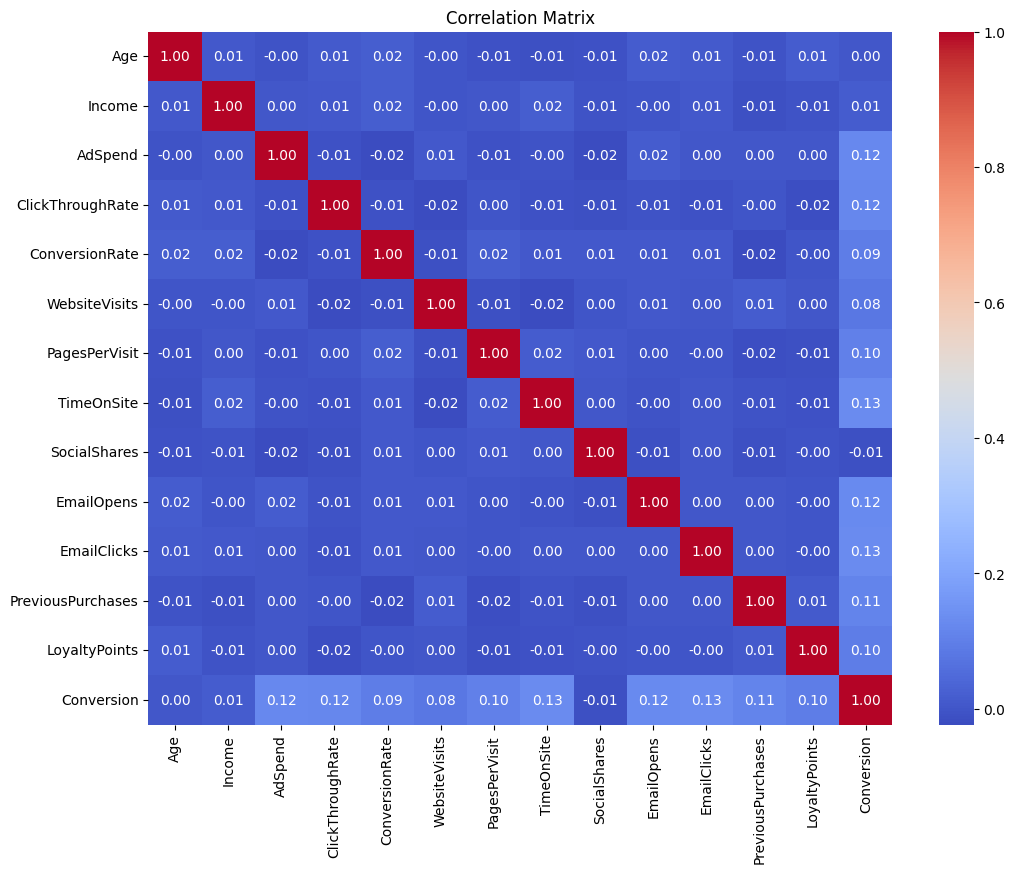

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

**عظم المتغيرات الرقمية لديها ارتباطات ضعيفة جدًا مع بعضها البعض.
- لا توجد علاقات قوية بين المتغيرات الرقمية، لذلك لا توجد مشكلة واضحة من Multicollinearity.
**

In [ ]:
#Welch's t-test
from scipy.stats import ttest_ind
import pandas as pd

alpha = 0.05

results = []

for col in numerical_features:
    group_0 = df[df['Conversion'] == 0][col]
    group_1 = df[df['Conversion'] == 1][col]

    stat, p_value = ttest_ind(
        group_0,
        group_1,
        equal_var=False
    )

    results.append({
        'Feature': col,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < alpha else 'No'
    })

numerical_results = pd.DataFrame(results)

numerical_results

,Feature,p-value,Significant
0,Age,8.874552e-01,No
1,Income,2.144879e-01,No
2,AdSpend,3.491953e-30,Yes
3,ClickThroughRate,2.062348e-25,Yes
4,ConversionRate,5.917964e-15,Yes
5,WebsiteVisits,3.794454e-11,Yes
6,PagesPerVisit,1.086591e-17,Yes
7,TimeOnSite,1.136829e-29,Yes
8,SocialShares,3.093414e-01,No
9,EmailOpens,3.068324e-27,Yes


In [ ]:
#Chi-Square Test
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

results = []

for col in categorical_features:
    table = pd.crosstab(df[col], df['Conversion'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    results.append({
        'Feature': col,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < alpha else 'No'
    })

categorical_results = pd.DataFrame(results)

categorical_results


,Feature,p-value,Significant
0,Gender,9.510312e-01,No
1,CampaignChannel,5.944500e-01,No
2,CampaignType,3.398335e-18,Yes


In [ ]:
#Engagement Variables
#Features بتقيس تفاعل العميل مع الحملة
engagement_features = [
    'WebsiteVisits',
    'PagesPerVisit',
    'TimeOnSite',
    'SocialShares',
    'EmailOpens',
    'EmailClicks'
]

df[engagement_features].corr()

,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks
WebsiteVisits,1.000000,-0.011891,-0.022440,0.000328,0.005865,0.003274
PagesPerVisit,-0.011891,1.000000,0.016455,0.007888,0.000503,-0.000047
TimeOnSite,-0.022440,0.016455,1.000000,0.001869,-0.004932,0.002099
SocialShares,0.000328,0.007888,0.001869,1.000000,-0.012028,0.003214
EmailOpens,0.005865,0.000503,-0.004932,-0.012028,1.000000,0.001410
EmailClicks,0.003274,-0.000047,0.002099,0.003214,0.001410,1.000000


In [ ]:
corr = df[engagement_features].corr()

corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(10)

TimeOnSite     PagesPerVisit    0.016455
PagesPerVisit  TimeOnSite       0.016455
               SocialShares     0.007888
SocialShares   PagesPerVisit    0.007888
EmailOpens     WebsiteVisits    0.005865
WebsiteVisits  EmailOpens       0.005865
               EmailClicks      0.003274
EmailClicks    WebsiteVisits    0.003274
SocialShares   EmailClicks      0.003214
EmailClicks    SocialShares     0.003214
dtype: float64

أقوى علاقة بين الـ Engagement Features هي:
TimeOnSite ↔ PagesPerVisit = 0.016
PagesPerVisit ↔ SocialShares = 0.008
EmailOpens ↔ WebsiteVisits = 0.006
WebsiteVisits ↔ EmailClicks = 0.003
باقي العلاقات أضعف من كده.

In [ ]:
#هل نوع الحملة أو قناة الحملة مرتبطة بسلوك العميل؟
df.groupby('CampaignChannel')[engagement_features].mean().round(2)

,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks
CampaignChannel,,,,,,
Email,24.88,5.56,7.68,49.52,9.48,4.51
PPC,24.16,5.55,7.84,49.61,9.30,4.46
Referral,24.89,5.54,7.65,50.00,9.59,4.53
SEO,24.74,5.51,7.62,49.03,9.42,4.32
Social Media,25.13,5.59,7.85,50.85,9.58,4.51


In [ ]:
df.groupby('CampaignType')[engagement_features].mean().round(2)

,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks
CampaignType,,,,,,
Awareness,24.76,5.62,7.76,50.50,9.49,4.40
Consideration,25.30,5.59,7.64,49.56,9.34,4.50
Conversion,24.38,5.50,7.82,49.71,9.49,4.54
Retention,24.58,5.48,7.69,49.42,9.59,4.42


مفيش Multicollinearity أو Redundancy واضحة، والـ CampaignChannel مش بيظهر اختلافات كبيرة في Engagement، بينما CampaignType مرتبط بالـ Conversion لكن اختلاف الـ Engagement بين أنواعه محدود.

In [ ]:
# EmailOpens , EmailClicks
#  بيقيسوا تفاعل العميل مع  Email.

df['EmailEngagement'] = df['EmailOpens'] + df['EmailClicks']

In [ ]:
#PreviousPurchases---->ونقدر نحولها إلى:

#هل العميل عنده تاريخ شراء سابق أم لا؟

df['PurchaseHistoryFlag'] = (
    df['PreviousPurchases'] > 0
).astype(int)

In [ ]:
X = df.drop(columns=['Conversion'])
y = df['Conversion']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
numerical_features = [
    'Age',
    'Income',
    'AdSpend',
    'ClickThroughRate',
    'ConversionRate',
    'WebsiteVisits',
    'PagesPerVisit',
    'TimeOnSite',
    'SocialShares',
    'EmailOpens',
    'EmailClicks',
    'PreviousPurchases',
    'LoyaltyPoints',
    'EmailEngagement',
    'PurchaseHistoryFlag'
]

categorical_features = [
    'Gender',
    'CampaignChannel',
    'CampaignType'
]

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

Conversion
1    5610
0     790
Name: count, dtype: int64
Conversion
1    87.65625
0    12.34375
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = baseline_model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred = baseline_model.predict(X_train_processed)
y_test_pred = baseline_model.predict(X_test_processed)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("=== Train ===")
print("Accuracy :", train_accuracy)
print("Precision:", train_precision)
print("Recall   :", train_recall)
print("F1 Score :", train_f1)

print("\n=== Test ===")
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1 Score :", test_f1)

=== Train ===
Accuracy : 0.89671875
Precision: 0.9009884945713823
Recall   : 0.9910873440285205
F1 Score : 0.943892708598591

=== Test ===
Accuracy : 0.889375
Precision: 0.8943979394719896
Recall   : 0.9907275320970043
F1 Score : 0.9401015228426396


1. Logistic Regression
حقق أداءً قويًا ومتوازنًا.
Test F1 = 94.01%.
الـ Recall مرتفع جدًا 99.07%.
الفرق بين Train وTest صغير.
لا يوجد Overfitting واضح.
الميزة: بسيط، سريع، وسهل التفسير.
العيب: قد لا يلتقط العلاقات غير الخطية المعقدة.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='brute')

knn_model.fit(X_train_processed, y_train)

y_train_pred = knn_model.predict(X_train_processed)
y_test_pred = knn_model.predict(X_test_processed)

print("=== KNN ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== KNN ===

Train
Accuracy : 0.89953125
Precision: 0.9003707883282283
Recall   : 0.9955436720142602
F1 Score : 0.9455684415474477

Test
Accuracy : 0.878125
Precision: 0.8841502227880331
Recall   : 0.9907275320970043
F1 Score : 0.934409687184662


2. KNN
حقق Test F1 = 93.44%.
الـ Recall مرتفع جدًا 99.07%.
أداؤه أقل قليلًا من Logistic Regression.
يوجد فرق بسيط بين Train وTest.
الميزة: بسيط ومناسب للعلاقات غير الخطية.
العيب: يعتمد على المسافات، ويمكن أن يكون أبطأ مع البيانات الأكبر، واختيار k يؤثر على الأداء.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb_model = GaussianNB()

nb_model.fit(X_train_processed, y_train)

y_train_pred = nb_model.predict(X_train_processed)
y_test_pred = nb_model.predict(X_test_processed)

print("=== Naive Bayes ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== Naive Bayes ===

Train
Accuracy : 0.86640625
Precision: 0.9081545064377683
Recall   : 0.9429590017825312
F1 Score : 0.9252295583734149

Test
Accuracy : 0.848125
Precision: 0.8977350720658888
Recall   : 0.9329529243937232
F1 Score : 0.9150052465897167


. Naive Bayes
حقق Test F1 = 91.50%.
Precision جيد 89.77%.
Recall أقل من باقي الموديلات القوية 93.30%.
أقل أداءً من Logistic Regression وKNN وSVM وEnsemble Models.
الميزة: سريع وبسيط.
العيب: يعتمد على افتراضات إحصائية قد لا تكون مناسبة تمامًا للبيانات.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_model = SVC()

svm_model.fit(X_train_processed, y_train)

y_train_pred = svm_model.predict(X_train_processed)
y_test_pred = svm_model.predict(X_test_processed)

print("=== SVM ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== SVM ===

Train
Accuracy : 0.91140625
Precision: 0.9094008767657087
Recall   : 0.9983957219251337
F1 Score : 0.9518225847565639

Test
Accuracy : 0.885625
Precision: 0.889955214331414
Recall   : 0.9921540656205421
F1 Score : 0.9382799325463743


4. SVM
حقق Test F1 = 93.83%.
حقق أعلى Recall تقريبًا بين الموديلات الأولى 99.22%.
أداء قوي وقريب من Logistic Regression.
الفرق بين Train وTest مقبول.
الميزة: قوي في إيجاد حدود الفصل بين الـ Classes.
العيب: يحتاج Scaling، وقد يكون مكلفًا حسابيًا مع البيانات الكبيرة، والـ Hyperparameters تؤثر على الأداء.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_processed, y_train)

y_train_pred = dt_model.predict(X_train_processed)
y_test_pred = dt_model.predict(X_test_processed)

print("=== Decision Tree ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== Decision Tree ===

Train
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Test
Accuracy : 0.83
Precision: 0.9053084648493543
Recall   : 0.9001426533523538
F1 Score : 0.9027181688125894


5. Decision Tree 
Train = 100% في كل المقاييس.
Test F1 = 90.27% فقط.
يوجد فرق كبير جدًا بين Train وTest.
المشكلة الأساسية: Overfitting.
الميزة: سهلة التفسير ولا تحتاج Scaling.
العيب: معرضة جدًا للـ Overfitting.
هنحتاج نعمل لها Tuning مثل max_depth, min_samples_split, min_samples_leaf.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train_processed)
y_test_pred = rf_model.predict(X_test_processed)

# Evaluation
print("=== Random Forest ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== Random Forest ===

Train
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Test
Accuracy : 0.8925
Precision: 0.8937259923175416
Recall   : 0.9957203994293866
F1 Score : 0.941970310391363


6. Random Forest
حقق Test F1 = 94.20%.
حاليًا من أقوى الموديلات.
Test Accuracy = 89.25%.
Test Recall = 99.57%.
لكن Train = 100% → يوجد Overfitting.
الميزة: أقوى من Decision Tree في التعميم، ويتعامل جيدًا مع العلاقات غير الخطية.
العيب: ما زال عنده Overfitting، وأقل قابلية للتفسير من Logistic Regression.
هنحتاج نعمل Tuning.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ada_model = AdaBoostClassifier(random_state=42)

ada_model.fit(X_train_processed, y_train)

y_train_pred = ada_model.predict(X_train_processed)
y_test_pred = ada_model.predict(X_test_processed)

print("=== AdaBoost ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== AdaBoost ===

Train
Accuracy : 0.91140625
Precision: 0.9098000975134081
Recall   : 0.9978609625668449
F1 Score : 0.9517980107115531

Test
Accuracy : 0.898125
Precision: 0.8989053444945267
Recall   : 0.9957203994293866
F1 Score : 0.9448392554991539


7. AdaBoost
حقق Test F1 = 94.48%.
حاليًا أعلى Test F1.
Test Accuracy = 89.81%.
Test Recall = 99.57%.
Train F1 = 95.18% مقابل Test F1 = 94.48%.
الفرق صغير نسبيًا → أداء جيد على البيانات الجديدة.
الميزة: قوي في تحسين الأخطاء المتكررة للنماذج البسيطة.
العيب: ممكن يكون حساسًا للـ noisy data والـ outliers، والـ Hyperparameters تؤثر على الأداء.

In [ ]:
results = {
    'Logistic Regression': {
        'Accuracy': 0.889375,
        'Precision': 0.8943979394719896,
        'Recall': 0.9907275320970043,
        'F1': 0.9401015228426396
    },

    'KNN': {
        'Accuracy': 0.878125,
        'Precision': 0.8841502227880331,
        'Recall': 0.9907275320970043,
        'F1': 0.934409687184662
    },

    'Naive Bayes': {
        'Accuracy': 0.848125,
        'Precision': 0.8977350720658888,
        'Recall': 0.9329529243937232,
        'F1': 0.9150052465897167
    },

    'SVM': {
        'Accuracy': 0.885625,
        'Precision': 0.889955214331414,
        'Recall': 0.9921540656205421,
        'F1': 0.9382799325463743
    },

    'Decision Tree': {
        'Accuracy': 0.830000,
        'Precision': 0.9053084648493543,
        'Recall': 0.9001426533523538,
        'F1': 0.9027181688125894
    },

    'Random Forest': {
        'Accuracy': 0.892500,
        'Precision': 0.8937259923175416,
        'Recall': 0.9957203994293866,
        'F1': 0.941970310391363
    },

    'AdaBoost': {
        'Accuracy': 0.898125,
        'Precision': 0.8989053444945267,
        'Recall': 0.9957203994293866,
        'F1': 0.9448392554991539
    }
}

results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by='F1',
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1
AdaBoost,0.898125,0.898905,0.995720,0.944839
Random Forest,0.892500,0.893726,0.995720,0.941970
Logistic Regression,0.889375,0.894398,0.990728,0.940102
SVM,0.885625,0.889955,0.992154,0.938280
KNN,0.878125,0.884150,0.990728,0.934410
Naive Bayes,0.848125,0.897735,0.932953,0.915005
Decision Tree,0.830000,0.905308,0.900143,0.902718


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

ada_model = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 1.0, 'n_estimators': 100}

Best Cross-Validation F1:
0.9506665807732654


In [ ]:
best_ada = grid_search.best_estimator_

best_ada.fit(X_train_processed, y_train)

y_train_pred = best_ada.predict(X_train_processed)
y_test_pred = best_ada.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Tuned AdaBoost ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== Tuned AdaBoost ===

Train
Accuracy : 0.91375
Precision: 0.9118892508143323
Recall   : 0.9980392156862745
F1 Score : 0.9530212765957446

Test
Accuracy : 0.899375
Precision: 0.9010989010989011
Recall   : 0.9942938659058488
F1 Score : 0.9454052221091895


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_ada,
    X_train_processed,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation F1 Scores:")
print(cv_scores)

print("\nMean CV F1:", cv_scores.mean())
print("Std CV F1 :", cv_scores.std())

Cross-Validation F1 Scores:
[0.94861996 0.95112622 0.95080577 0.95157179 0.95120916]

Mean CV F1: 0.9506665807732654
Std CV F1 : 0.0010519614958484553


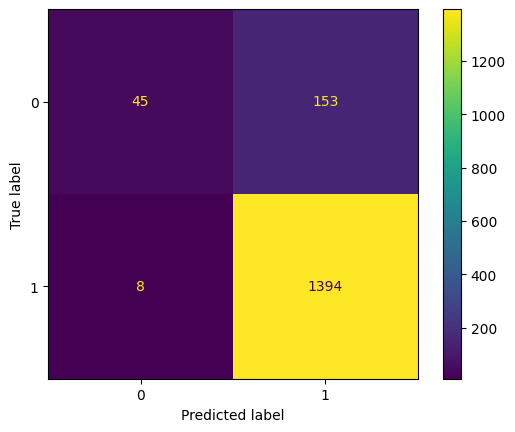

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()

In [ ]:
from sklearn.metrics import classification_report

print("=== Tuned AdaBoost - Classification Report ===")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Conversion", "Conversion"]
    )
)

=== Tuned AdaBoost - Classification Report ===
               precision    recall  f1-score   support

No Conversion       0.85      0.23      0.36       198
   Conversion       0.90      0.99      0.95      1402

     accuracy                           0.90      1600
    macro avg       0.88      0.61      0.65      1600
 weighted avg       0.89      0.90      0.87      1600



In [ ]:
print("=== Final Train vs Test ===")

print("\nTrain")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTest")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

=== Final Train vs Test ===

Train
Accuracy : 0.91375
Precision: 0.9118892508143323
Recall   : 0.9980392156862745
F1 Score : 0.9530212765957446

Test
Accuracy : 0.899375
Precision: 0.9010989010989011
Recall   : 0.9942938659058488
F1 Score : 0.9454052221091895


In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": baseline_model,
    "KNN": knn_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Tuned AdaBoost": best_ada
}

cv_results = []

for name, model in models.items():

    if name == "Naive Bayes":
        X_cv = X_train_processed

        if hasattr(X_cv, "toarray"):
            X_cv = X_cv.toarray()
    else:
        X_cv = X_train_processed

    scores = cross_val_score(
        model,
        X_cv,
        y_train,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    by="Mean F1",
    ascending=False
).reset_index(drop=True)

cv_df

,Model,Mean F1,Std F1
0,Tuned AdaBoost,0.950667,0.001052
1,Random Forest,0.944327,0.002794
2,Logistic Regression,0.943630,0.002664
3,SVM,0.943620,0.001210
4,KNN,0.934781,0.002610
5,Naive Bayes,0.923727,0.004695
6,Decision Tree,0.901605,0.005492


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_test_final_pred = best_ada.predict(X_test_processed)

final_accuracy = accuracy_score(y_test, y_test_final_pred)
final_precision = precision_score(y_test, y_test_final_pred)
final_recall = recall_score(y_test, y_test_final_pred)
final_f1 = f1_score(y_test, y_test_final_pred)

print("=== Final Tuned AdaBoost ===")

print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

print("\n=== Classification Report ===")

print(
    classification_report(
        y_test,
        y_test_final_pred,
        target_names=["No Conversion", "Conversion"]
    )
)

print("\n=== Confusion Matrix ===")

print(confusion_matrix(y_test, y_test_final_pred))

=== Final Tuned AdaBoost ===
Accuracy : 0.899375
Precision: 0.9010989010989011
Recall   : 0.9942938659058488
F1 Score : 0.9454052221091895

=== Classification Report ===
               precision    recall  f1-score   support

No Conversion       0.85      0.23      0.36       198
   Conversion       0.90      0.99      0.95      1402

     accuracy                           0.90      1600
    macro avg       0.88      0.61      0.65      1600
 weighted avg       0.89      0.90      0.87      1600


=== Confusion Matrix ===
[[  45  153]
 [   8 1394]]


In [10]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_ada)
])

final_pipeline.fit(X_train, y_train)

y_test_final = final_pipeline.predict(X_test)

print("=== Final Pipeline Test ===")

print("Accuracy :", accuracy_score(y_test, y_test_final))
print("Precision:", precision_score(y_test, y_test_final))
print("Recall   :", recall_score(y_test, y_test_final))
print("F1 Score :", f1_score(y_test, y_test_final))

NameError: name 'preprocessor' is not defined

In [9]:
import joblib

joblib.dump(
    final_pipeline,
    "final_adaboost_pipeline.pkl"
)

print("Final pipeline saved successfully!")

NameError: name 'final_pipeline' is not defined

In [ ]:
import os

os.path.exists("final_adaboost_pipeline.pkl")

False

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\NoteBook\Desktop\Customer_Conversion_Project
['.venv', 'app.py', 'assets', 'Customer_Conversion.ipynb', 'data', 'model', 'pages']


In [ ]:
import os

print("MODEL FOLDER:")
print(os.listdir("model"))


MODEL FOLDER:
[]
